In [1]:
%cd "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy"
!ls -lah examples/fenton | head

/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy
total 36M
drwxrwxrwx 0 root root  512 Feb 16 16:57 .
drwxrwxrwx 0 root root  512 Feb 10 17:03 ..
drwxrwxrwx 0 root root  512 Feb 16 16:49 MODIS16-PET_8days
drwxrwxrwx 0 root root  512 Feb 16 12:06 MODIS16-PET_yearly
-rwxrwxrwx 0 root root  87K Feb 12 12:43 PRISM_ppt_tmean_provisional_4km_20150101_20251231_41.8283_-72.2371.csv
-rwxrwxrwx 0 root root 109K Feb 12 15:49 Qobs.csv
-rwxrwxrwx 0 root root 8.6M Feb 12 13:37 continuous1.csv
-rwxrwxrwx 0 root root 8.3M Feb 12 13:39 continuous2.csv
-rwxrwxrwx 0 root root 8.6M Feb 12 13:42 continuous3.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import requests
from io import StringIO
from rasterio.plot import show
import hbv
from hbv import hbv_run
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Load inputs: temperature, precipitation and monthly PET

In [3]:
import requests as r
import getpass, pprint, time, os, json
import geopandas as gpd

In [4]:
# Set input directory, change working directory
inDir = os.path.dirname(os.path.dirname(os.getcwd()))          # IMPORTANT: Update if this does not reflect the proper directory on your OS
os.chdir(inDir)                                      # Change to working directory
api = 'https://appeears.earthdatacloud.nasa.gov/api/'  # Set the AρρEEARS API to a variable

In [5]:
#'iamkimyeonju' 
#'Star971125^^'

In [6]:
path = "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy/examples/fenton/inputPrecipTemp.csv"

import os
print("absolute exists?", os.path.exists(path))
print("absolute can read?", os.access(path, os.R_OK))

import pandas as pd
df = pd.read_csv(path)
df.head()


absolute exists? True
absolute can read? True


,Time,Month,Temperature,Precipitation
0,01/01/2015,1,-5.6,0.00
1,01/02/2015,1,-2.9,0.00
2,01/03/2015,1,-1.7,0.00
3,01/04/2015,1,-2.5,10.63
4,01/05/2015,1,4.5,3.87


In [7]:
example_dir = Path("examples") / "fenton"

forcing_path =  "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy/examples/fenton/inputPrecipTemp.csv"
pet_path = example_dir /  "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy/examples/fenton/inputMonthlyTempEvap.csv"
Qobs_path = example_dir /  "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy/examples/fenton/Qobs.csv"

forcing = pd.read_csv(forcing_path, parse_dates=["Time"])
forcing["Time"] = pd.to_datetime(forcing["Time"], format="%Y-%m-%d")
pet = pd.read_csv(pet_path)

Qobs = pd.read_csv(Qobs_path, parse_dates=["Time"])
Qobs["Time"] = pd.to_datetime(Qobs["Time"], format="%Y-%m-%d")

In [8]:
forcing.head() # Time, Month, Temperature (deg C),	Precipitation (mm/day)

,Time,Month,Temperature,Precipitation
0,2015-01-01,1,-5.6,0.00
1,2015-01-02,1,-2.9,0.00
2,2015-01-03,1,-1.7,0.00
3,2015-01-04,1,-2.5,10.63
4,2015-01-05,1,4.5,3.87


Text(0.5, 1.0, 'Temperature (deg C)')

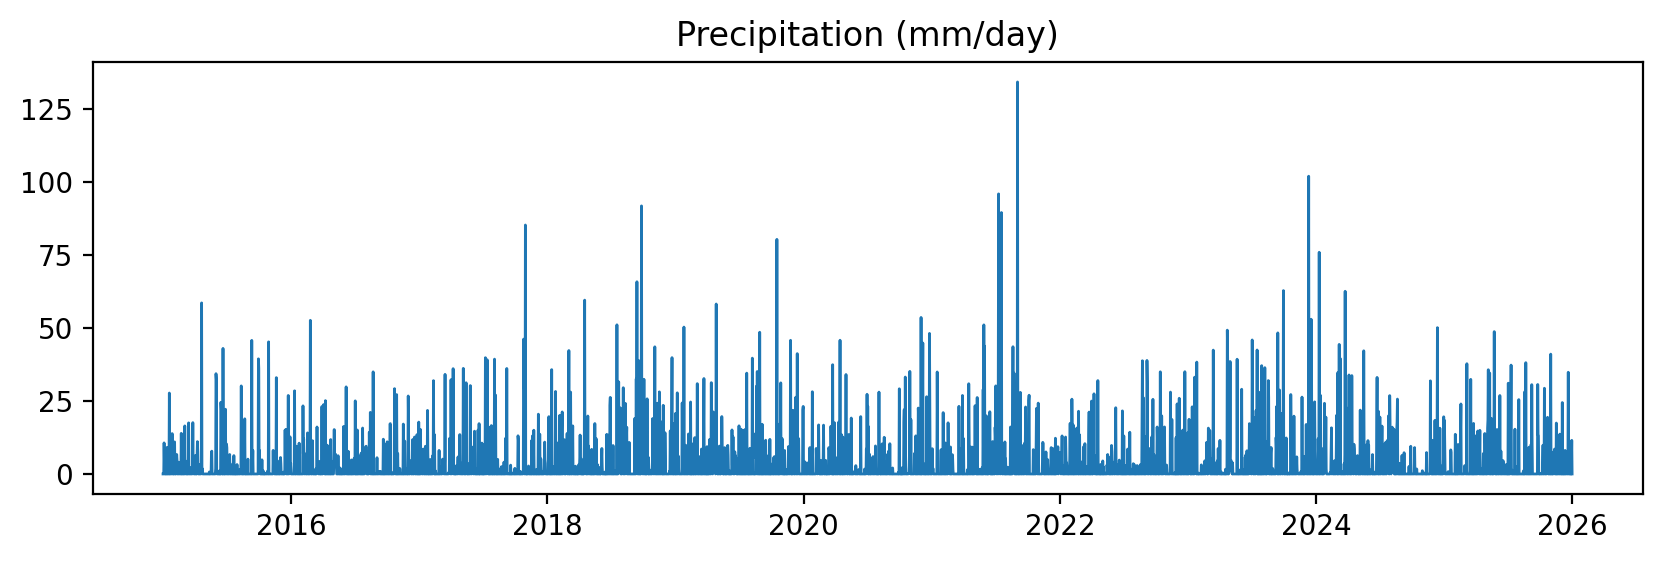

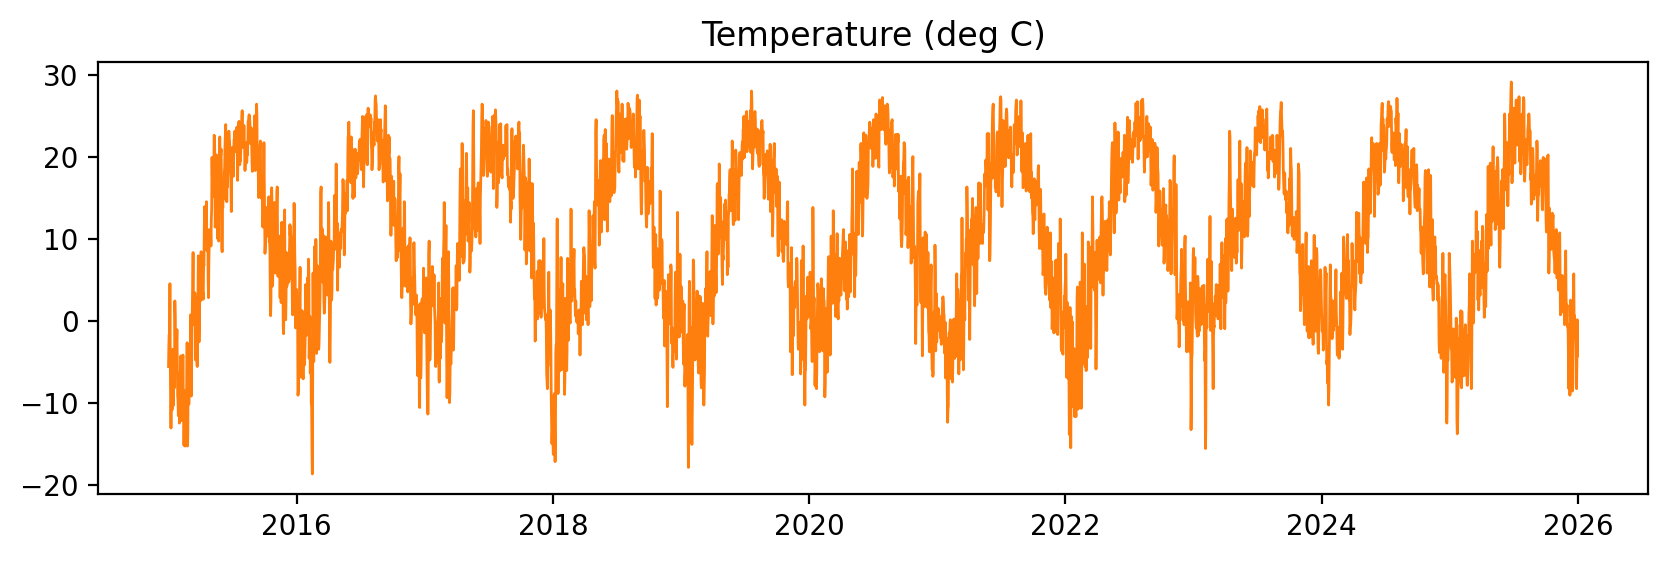

In [9]:
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(forcing["Time"], forcing["Precipitation"], lw=1, c = 'C0')
ax.set_title('Precipitation (mm/day)')
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(forcing["Time"], forcing["Temperature"], lw=1, c = 'C1')
ax.set_title('Temperature (deg C)')

In [10]:
pet.head() # Corresponding Month, Average Temperature each month, Average PET per month (mm/month), Average PET per day (mm/day)

,month,T_avg_month,PEm_month,PEm_day
0,1,-2.25,20.88,0.674
1,2,-1.51,34.25,1.223
2,3,2.81,70.00,2.258
3,4,8.48,97.47,3.249
4,5,14.53,144.31,4.655


## Need to find your own precipitation, temperature and potential monthly ET dataset?

You can use your own source for sure. Here are just generic methods for you to find your inputs.



*   High-resolution gridded PRISM weather data, with mean temp and precipitation: https://prism.oregonstate.edu/explorer/
*   MODIS-ET: https://modis.gsfc.nasa.gov/data/dataprod/mod16.php.
*How to get MODIS-ET tutorial: https://youtu.be/cUAtYyGI9mI?si=qzb8bkKHAI_iHKb6*






# Initialize parameters


[d, fc, beta, cpar, k0, lthr, k1, k2, kp, pwp], where

d    : degree day melt factor (mm/degC/day)

fc   : field capacity (mm)

beta : runoff nonlinearity exponent

cpar : PET temperature correction factor

k0   : quickflow coefficient for s1 above threshold lthr (1/day)

lthr : threshold in upper storage for quickflow activation (mm)

k1   : linear outflow coefficient from s1 (1/day)

k2   : linear outflow coefficient from s2 (1/day)

kp   : percolation coefficient from s1 to s2 (1/day)

pwp  : permanent wilting point (mm)


In [11]:
ParamInitial = {
    "d": 2.74,
    "fc": 100.0,
    "beta": 5.0,
    "cpar": 0.01,
    "k0": 0.2,
    "lthr": 5,
    "k1": 0.1,
    "k2": 0.15,
    "kp": 0.15,
    "pwp": 100.0,
}

params = np.array([ParamInitial[k] for k in ParamInitial.keys()], dtype=float)

# Run the HBV model

In [12]:
results, aux = hbv_run(
    forcing=forcing,
    pet_monthly=pet,
    params=params,
    area_km2=89, # catchment size 410 km2 !! You need to change the catchment size/drainage area for your own site!!!
    Tsnow_thresh=0.0, # threshold for being snow or rain
    init_state={"snow": 0.0, "soil": 0.0, "s1": 0.0, "s2": 0.0},
)
results.head()

,Time,snow,liq_water,pe,ea,soil,dq,s1,s2,q_mmday,Q_m3s
0,2015-01-01,0.00,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01-02,0.00,0.0,0.669619,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01-03,0.00,0.0,0.677707,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01-04,10.63,0.0,0.672315,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-05,0.00,14.5,0.719495,0.0,14.5,0.0,0.0,0.0,0.0,0.0


# Compare simulated and observed discharge Q (m3/s)

Recall that we put all storage terms initially as zero: {"snow": 0.0, "soil": 0.0, "s1": 0.0, "s2": 0.0}, do you see any impact? Do you think if you can give better initial values?

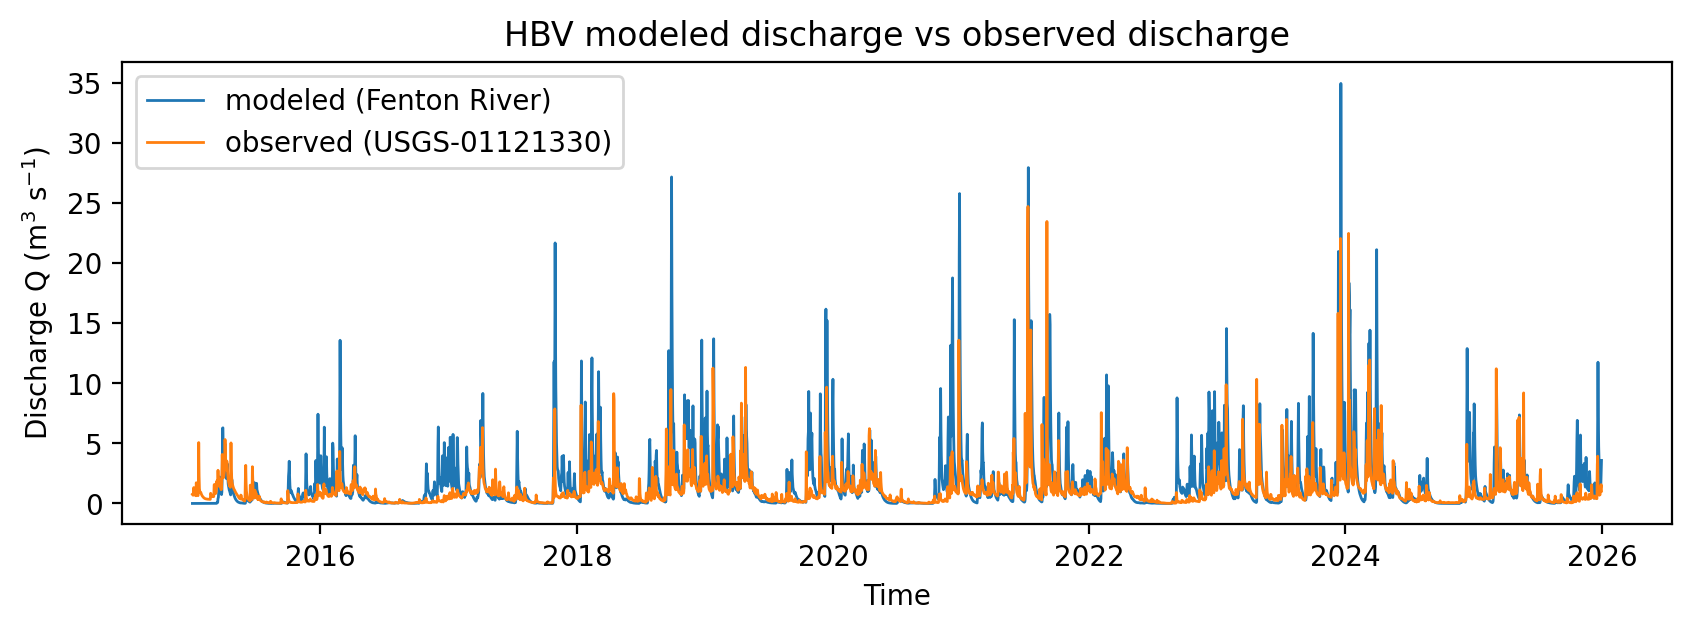

In [13]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(results["Time"], results["Q_m3s"], lw=1, label = 'modeled (Fenton River)')
ax.plot(Qobs["Time"], Qobs["Q (m3/s)"], lw=1, label = 'observed (USGS-01121330)')
ax.set_xlabel("Time")
ax.set_ylabel("Discharge Q (m$^3$ s$^{-1}$)")
ax.set_title("HBV modeled discharge vs observed discharge")
ax.legend()
plt.show()

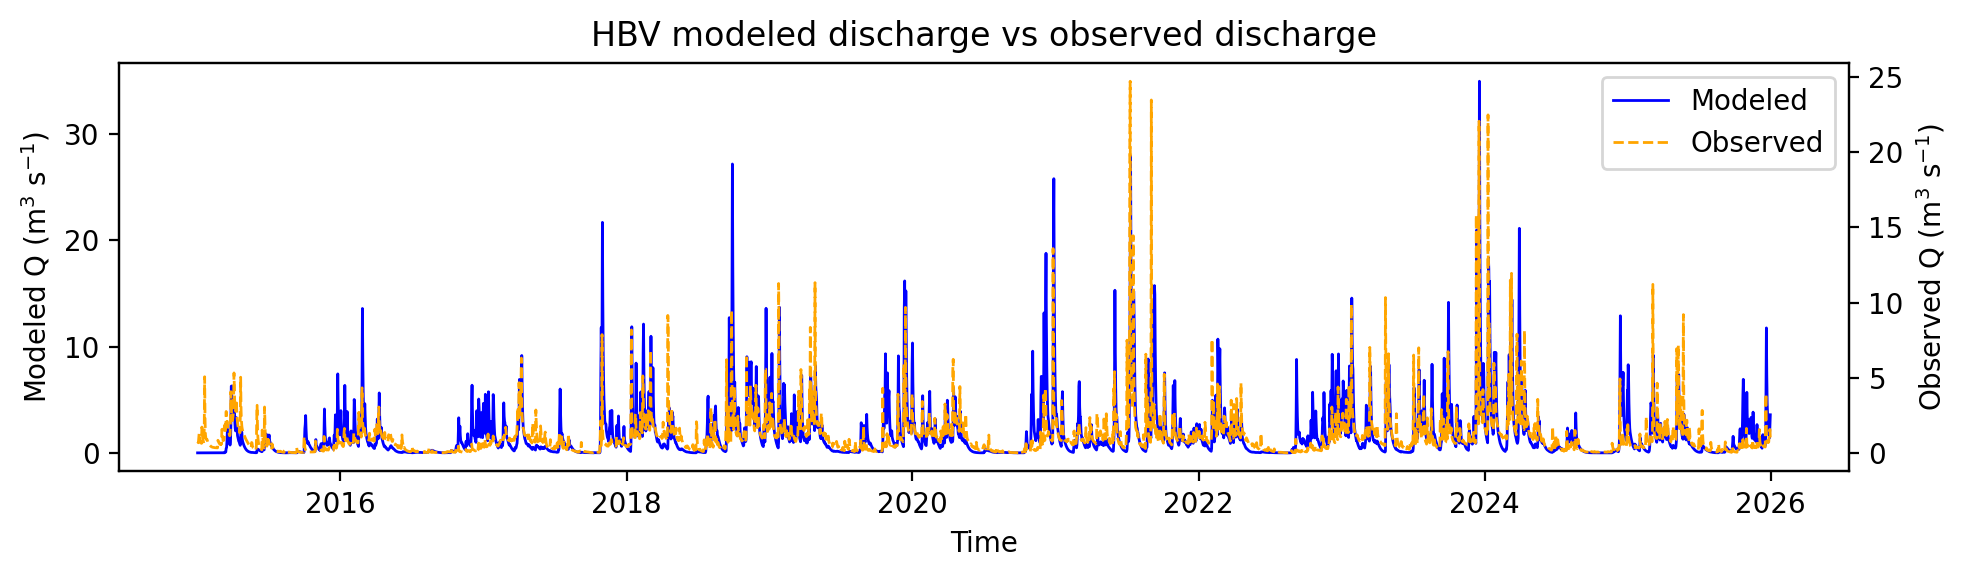

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 3))

# Left y-axis: modeled
l1 = ax1.plot(
    results["Time"],
    results["Q_m3s"],
    lw=1,
    label="Modeled",
    color="blue"
)
ax1.set_xlabel("Time")
ax1.set_ylabel("Modeled Q (m$^3$ s$^{-1}$)")
ax1.tick_params(axis="y")

# Right y-axis: observed
ax2 = ax1.twinx()
l2 = ax2.plot(
    Qobs["Time"],
    Qobs["Q (m3/s)"],
    lw=1,
    linestyle="--",
    label="Observed",
    color="orange"
)
ax2.set_ylabel("Observed Q (m$^3$ s$^{-1}$)")
ax2.tick_params(axis="y")

# Legend (merge both axes)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

ax1.set_title("HBV modeled discharge vs observed discharge")
plt.tight_layout()
plt.show()


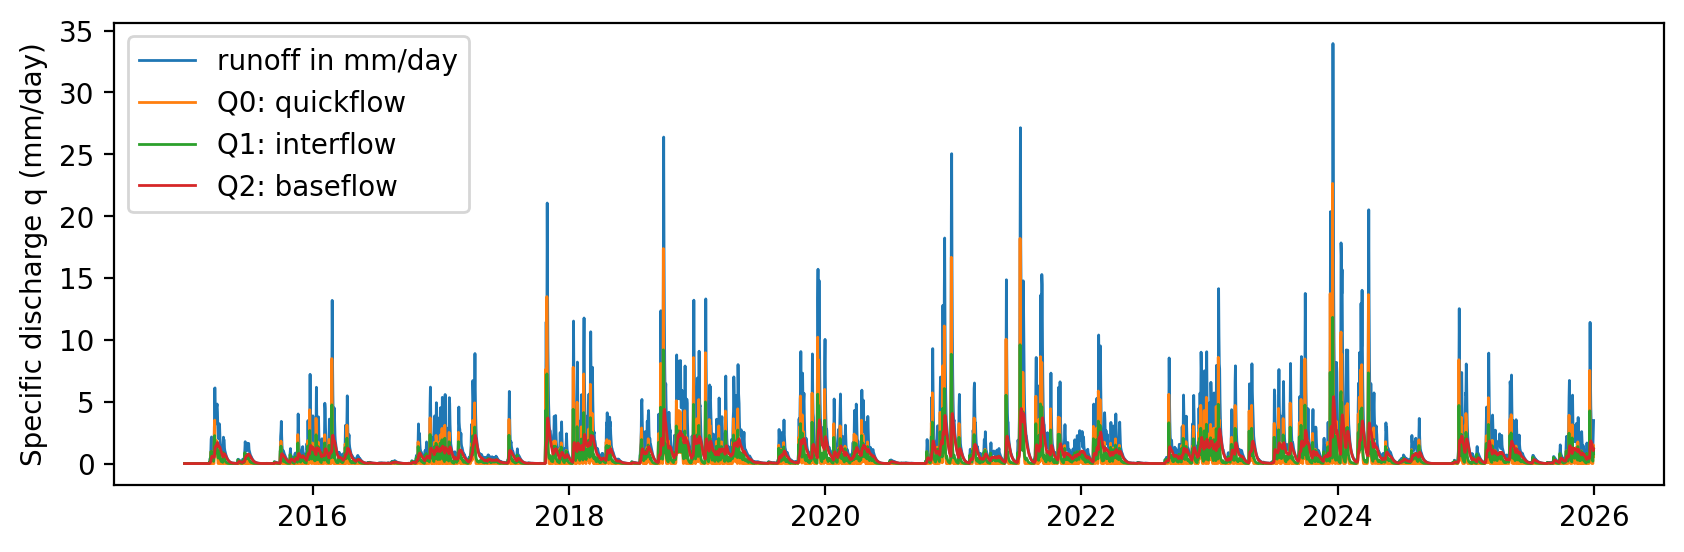

In [15]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(results["Time"], results["q_mmday"], lw=1, label = 'runoff in mm/day')
Q0 = ((results["s1"]-ParamInitial['lthr'])*ParamInitial['k0']).clip(lower=0.0)
ax.plot(results["Time"], Q0, lw=1, label = 'Q0: quickflow')
Q1 = results["s1"]*ParamInitial['k1']
ax.plot(results["Time"], Q1, lw=1, label = 'Q1: interflow')
Q2 = results["s2"]*ParamInitial['k2']
ax.plot(results["Time"], Q2, lw=1, label = 'Q2: baseflow')
ax.legend()
ax.set_ylabel("Specific discharge q (mm/day)")
plt.show()

# Metrics

In [16]:
%cd "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy"

from metrics import discharge_metrics

scores = discharge_metrics(
    modeled=results,
    observed=Qobs,
    modeled_value_col="Q_m3s",
    observed_value_col="Q (m3/s)",
)

scores

/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy


{'MSE': 5.0562343836388965,
 'RMSE': 2.2486072097275898,
 'MAE': 1.0844263238279657,
 'NSE': -1.3492623031740059,
 'KGE': -0.0651827246836687}

In [17]:
%cd "/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy"

from metrics import discharge_metrics
results_scaled = results
results_scaled["Q_m3s"] = results_scaled["Q_m3s"]/89

Qobs_scaled = Qobs
Qobs_scaled["Q (m3/s)"] = Qobs_scaled["Q (m3/s)"]/50

scores = discharge_metrics(
    modeled=results_scaled,
    observed=Qobs_scaled,
    modeled_value_col="Q_m3s",
    observed_value_col="Q (m3/s)",
)

scores

/mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/HBV/hbvpy


{'MSE': 0.000774311263988124,
 'RMSE': 0.0278264490006922,
 'MAE': 0.013707161800558289,
 'NSE': 0.10058547261155382,
 'KGE': 0.5352778680396623}

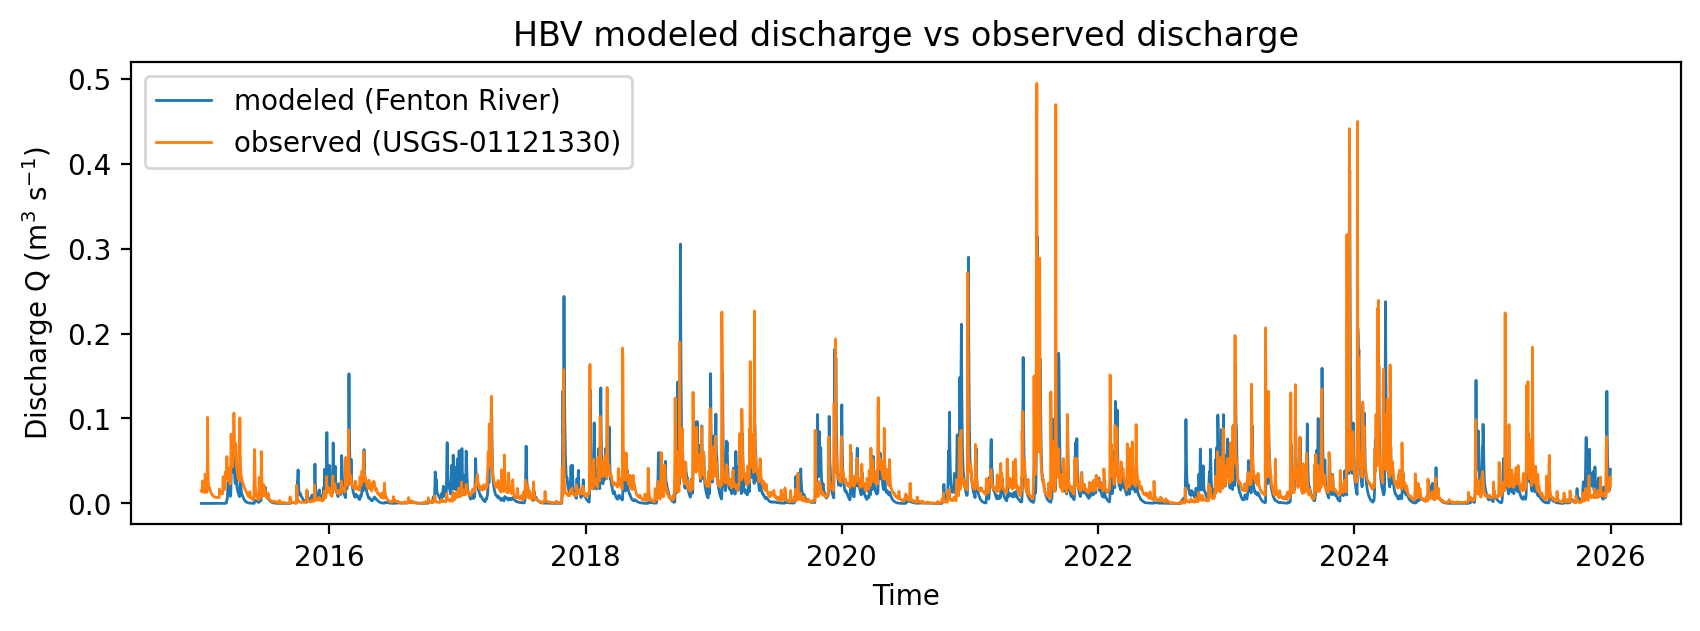

In [18]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(results_scaled["Time"], results_scaled["Q_m3s"], lw=1, label = 'modeled (Fenton River)')
ax.plot(Qobs_scaled["Time"], Qobs_scaled["Q (m3/s)"], lw=1, label = 'observed (USGS-01121330)')
ax.set_xlabel("Time")
ax.set_ylabel("Discharge Q (m$^3$ s$^{-1}$)")
ax.set_title("HBV modeled discharge vs observed discharge")
ax.legend()
plt.show()

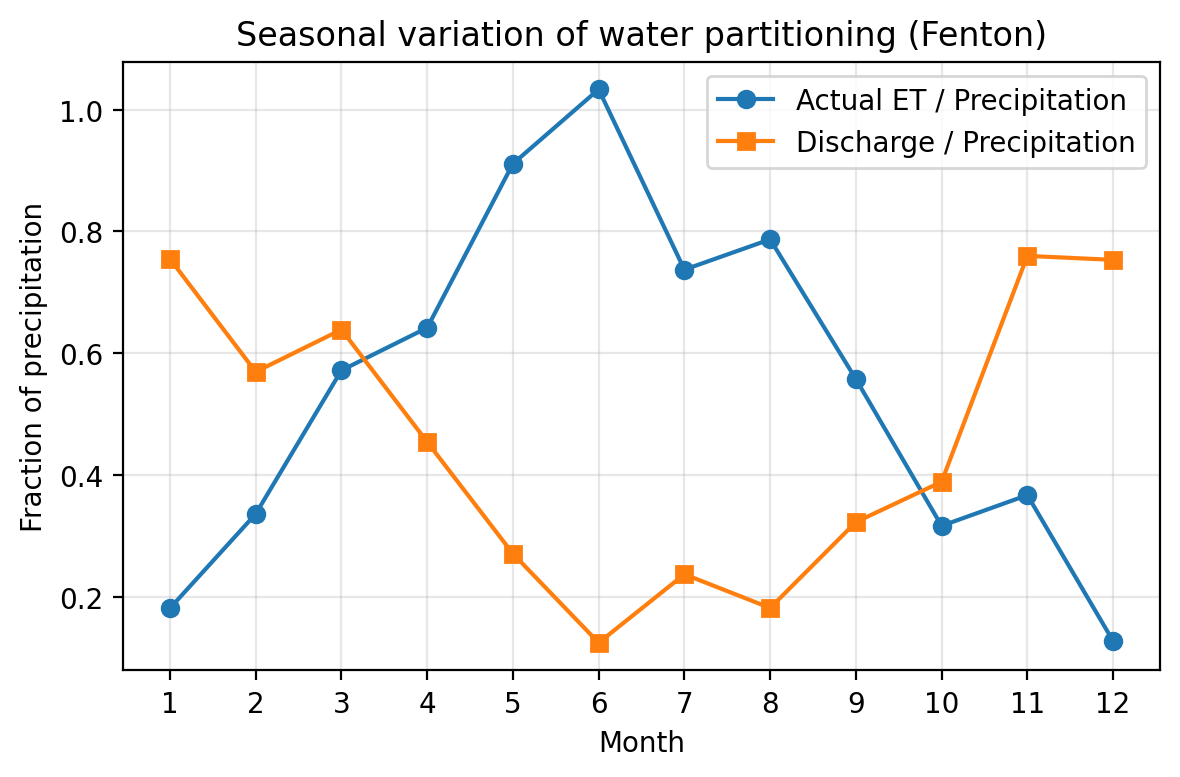

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = results.copy()
df["Time"] = pd.to_datetime(df["Time"])

forcing_df = forcing.copy()
forcing_df["Time"] = pd.to_datetime(forcing_df["Time"])

df = df.merge(
    forcing_df[["Time", "Precipitation"]],
    on="Time",
    how="left"
)

df["Month"] = df["Time"].dt.month

monthly = df.groupby("Month").agg(
    P=("Precipitation", "sum"),  # 실제 강수량
    ET=("ea", "sum"),            # actual ET
    Q=("q_mmday", "sum")         # discharge
)

monthly["ET_ratio"] = monthly["ET"] / monthly["P"]
monthly["Q_ratio"]  = monthly["Q"]  / monthly["P"]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    monthly.index,
    monthly["ET_ratio"],
    marker="o",
    label="Actual ET / Precipitation"
)

ax.plot(
    monthly.index,
    monthly["Q_ratio"],
    marker="s",
    label="Discharge / Precipitation"
)

ax.set_xlabel("Month")
ax.set_ylabel("Fraction of precipitation")
ax.set_title("Seasonal variation of water partitioning (Fenton)")
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Other state/flux variables

snow: snow water equivalent storage (mm)

liq_water: liquid water, rain + melt available to soil/runoff (mm/day)

pe: potential evapotranspiration (mm/day)
   
ea: actual evapotranspiration (mm/day)

soil: soil moisture storage (mm)
    
dq: effective precipitation to reservoirs (mm/day)

s1: upper reservoir storage (mm)

s2: lower reservoir storage (mm)
    
q_mmday: runoff depth equivalent (mm/day)

Q_m3s: discharge (m^3/s)

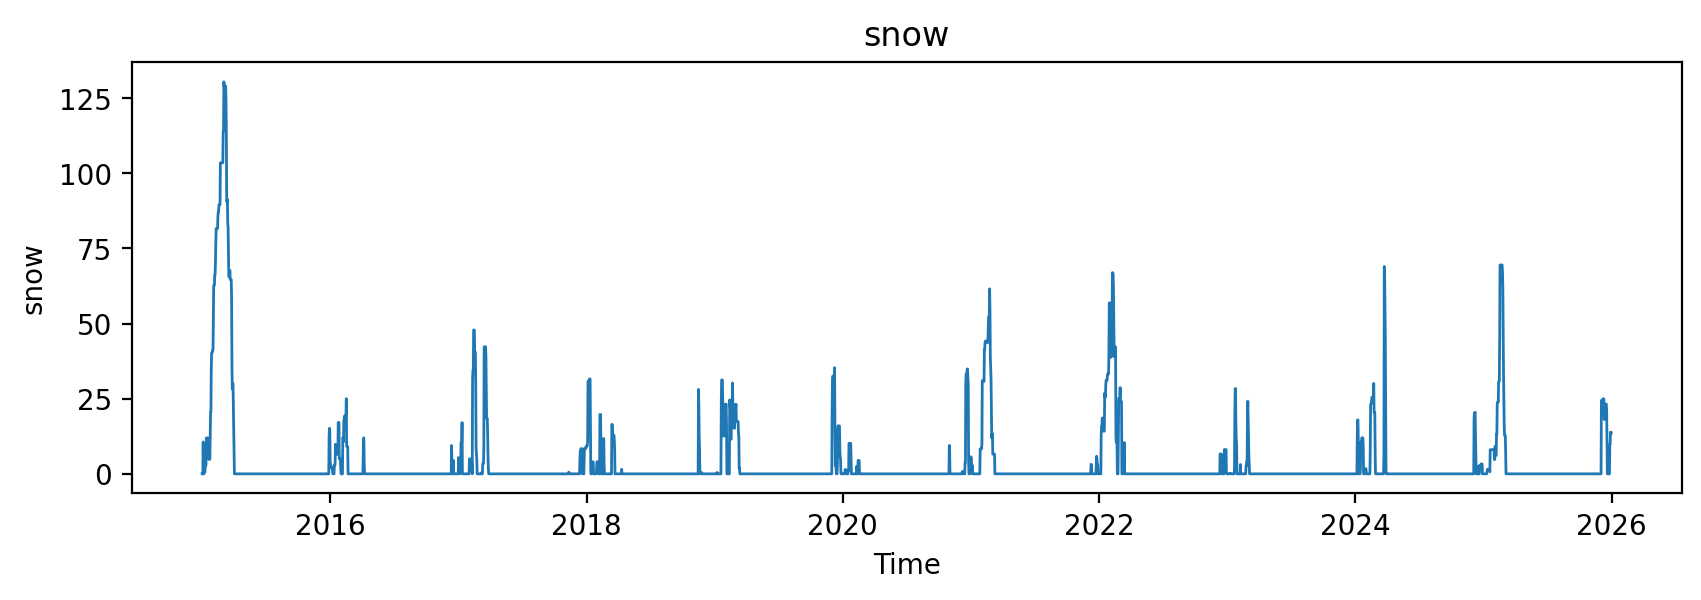

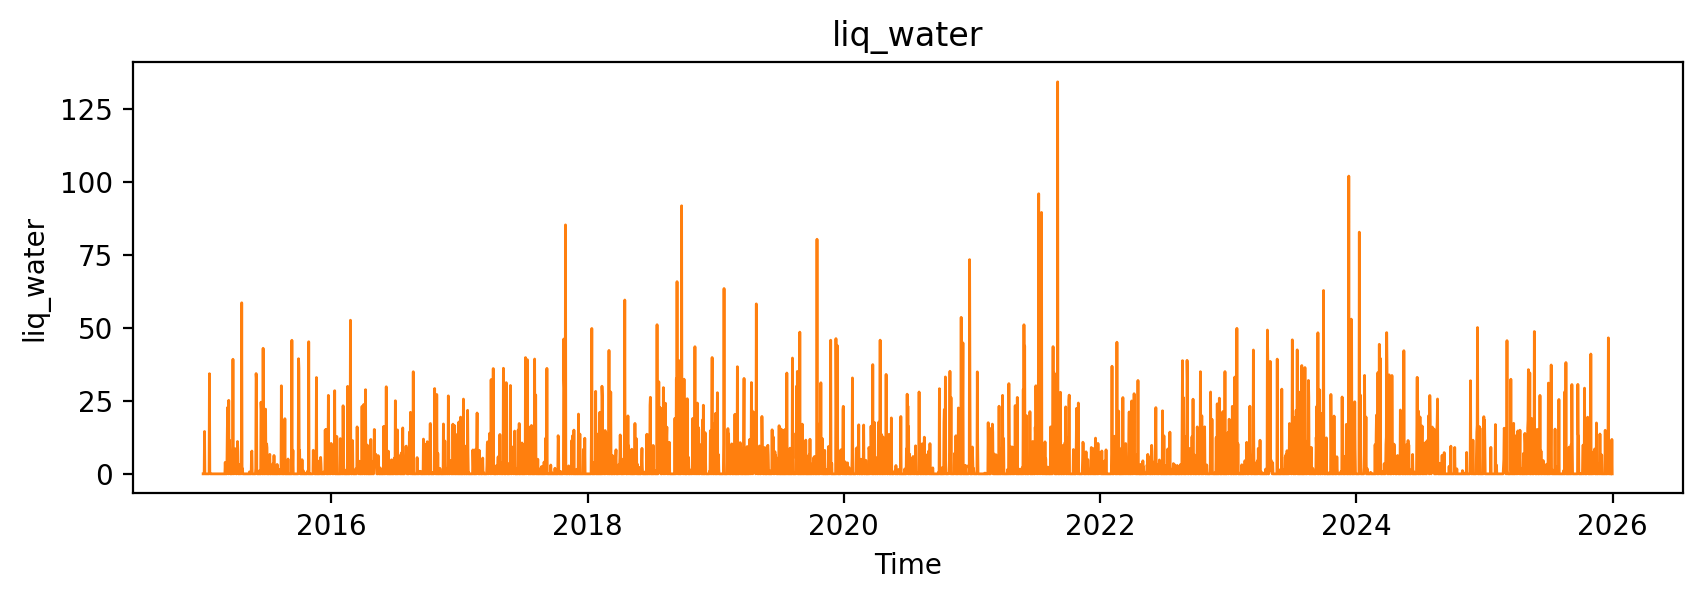

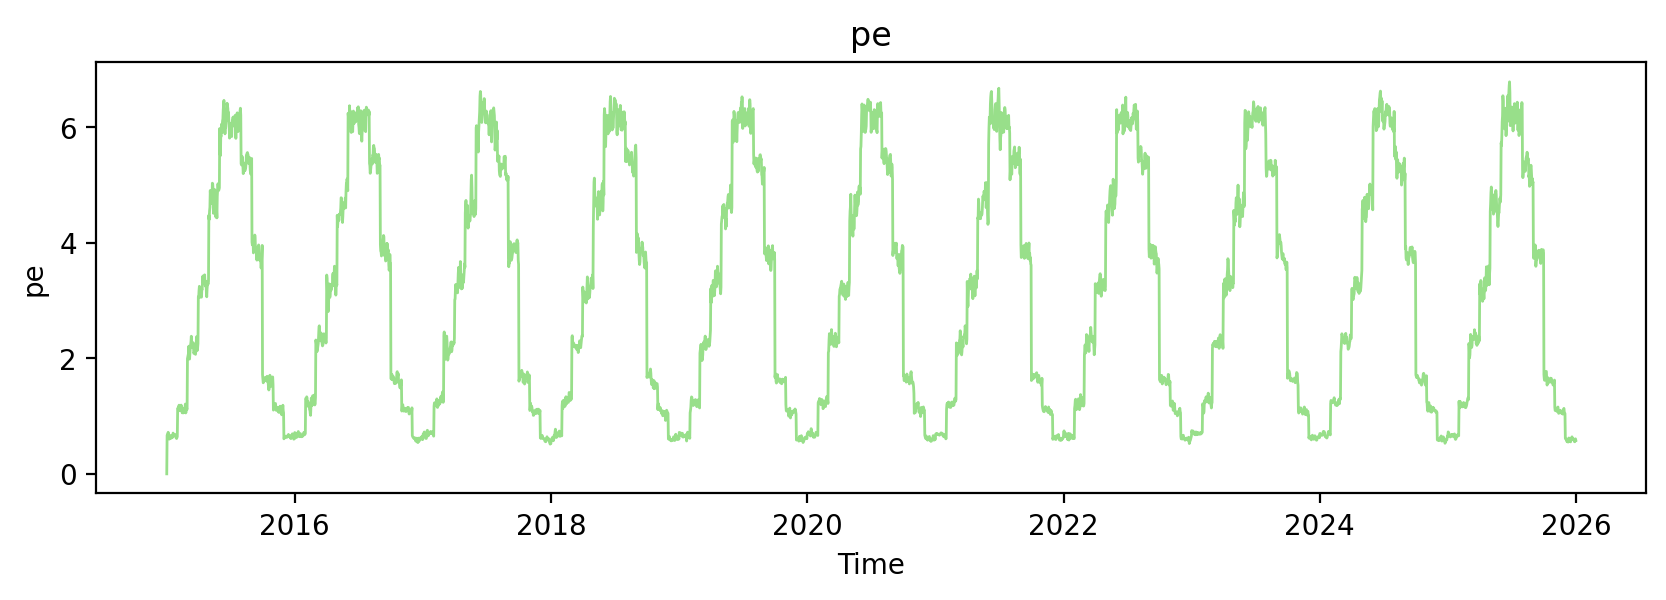

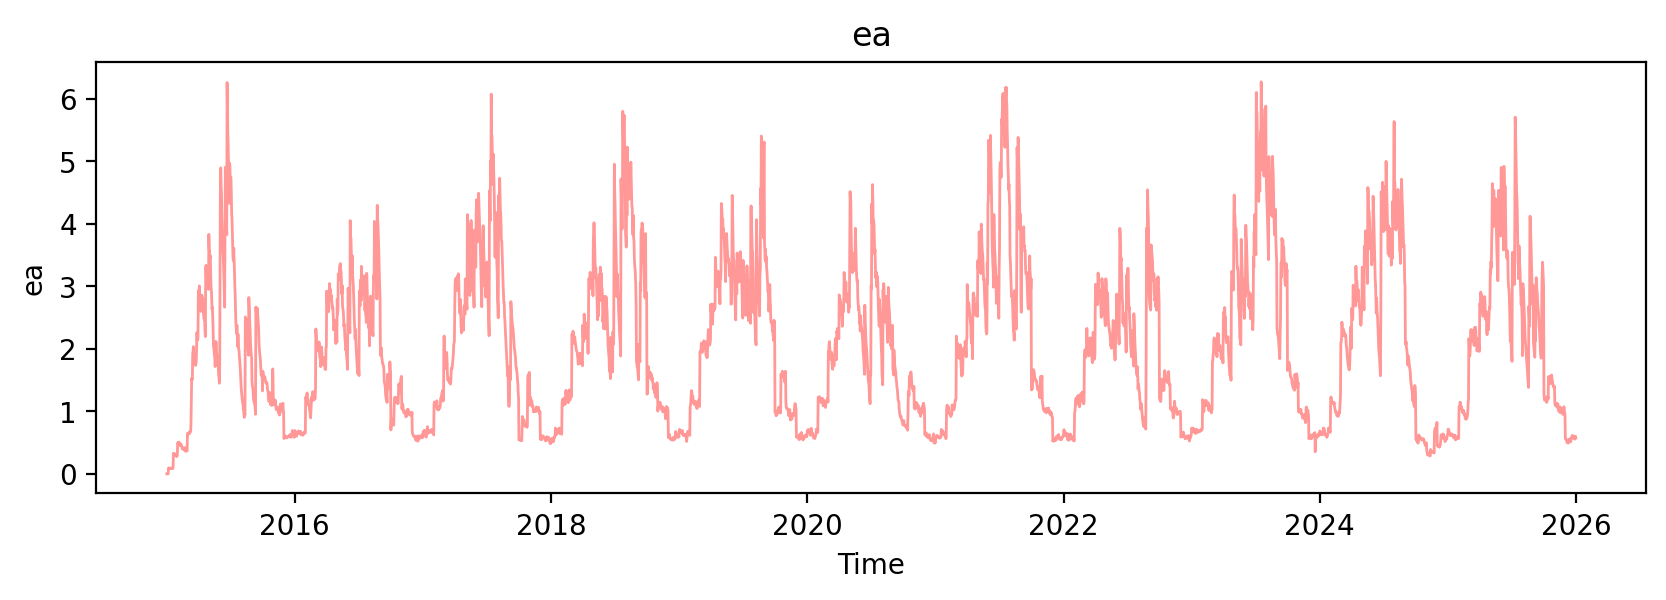

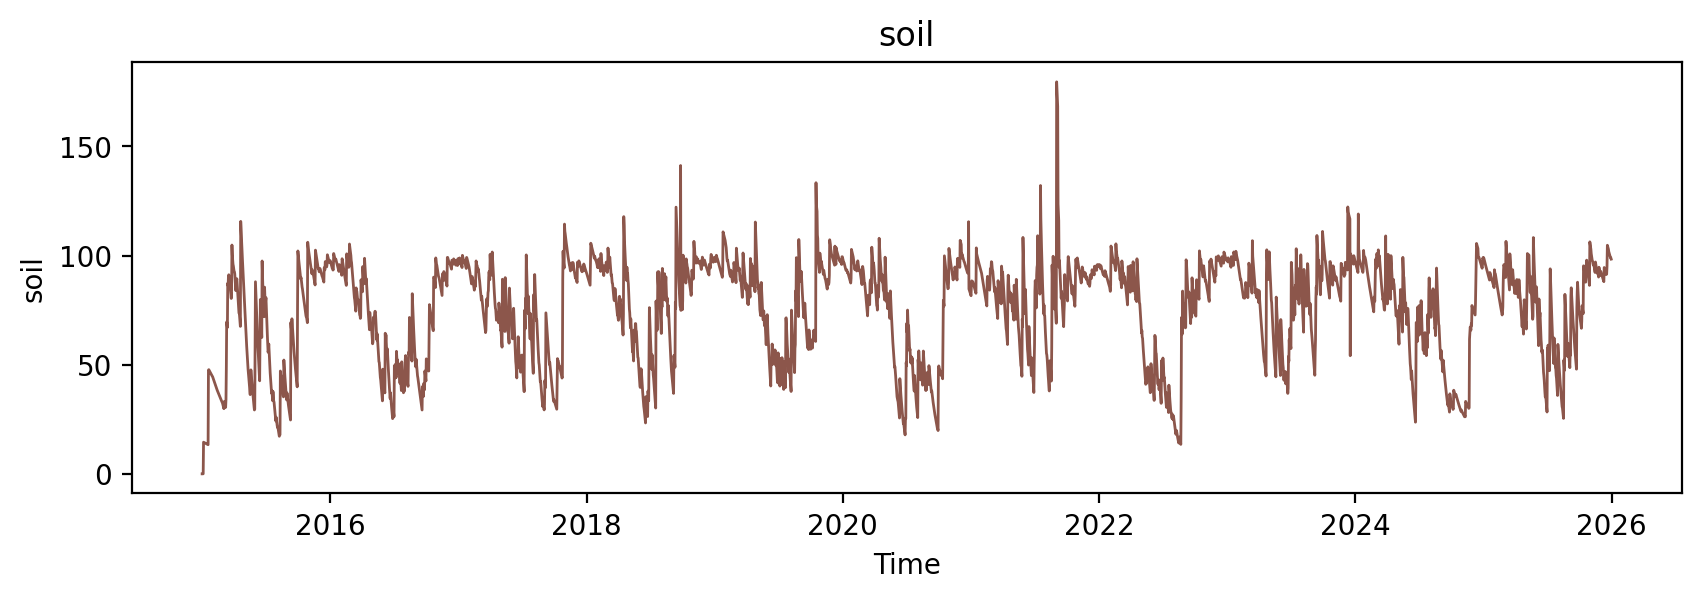

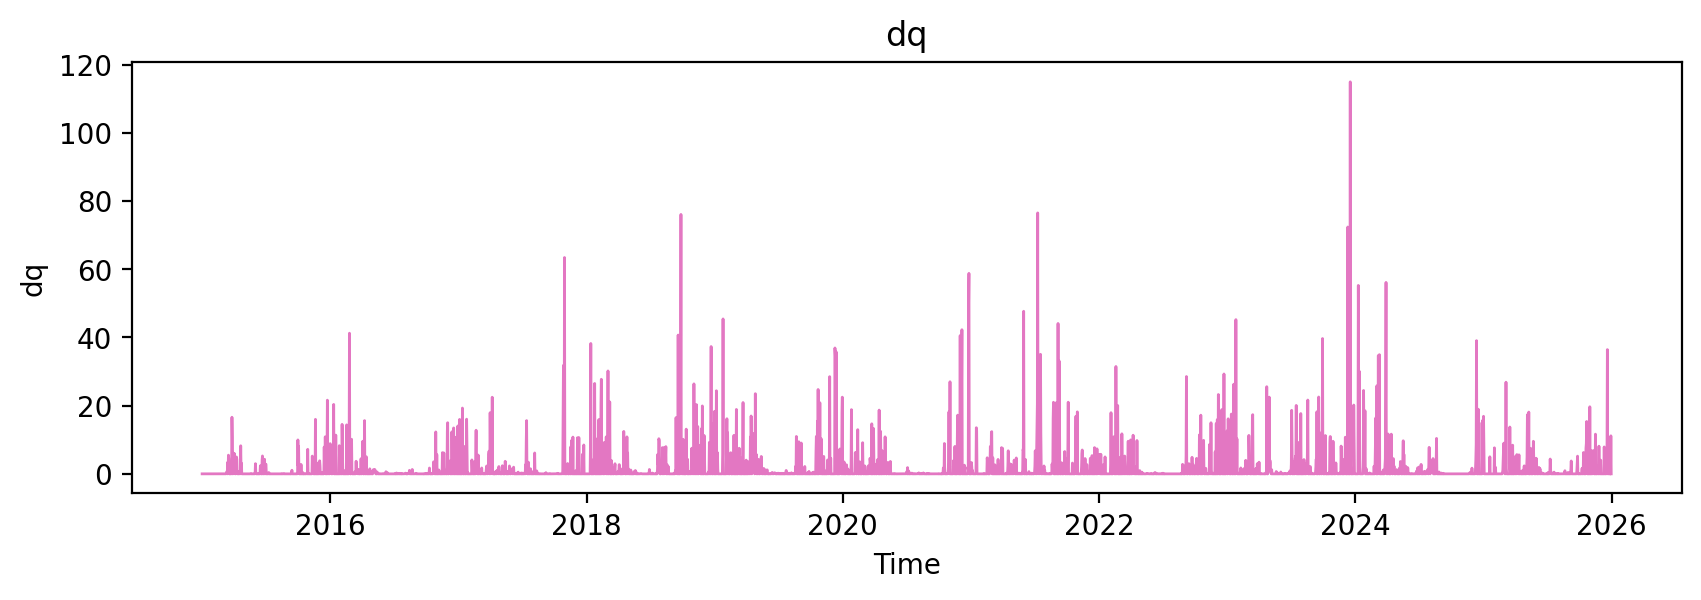

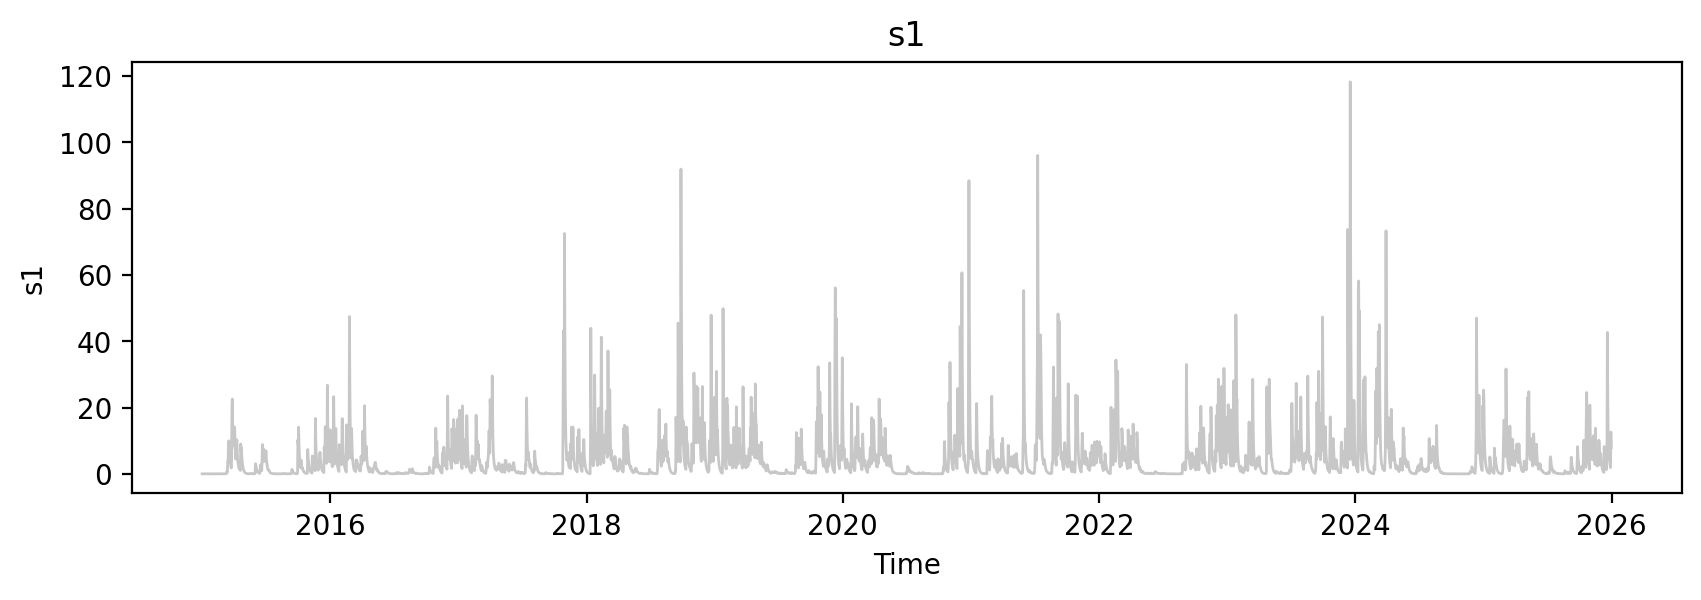

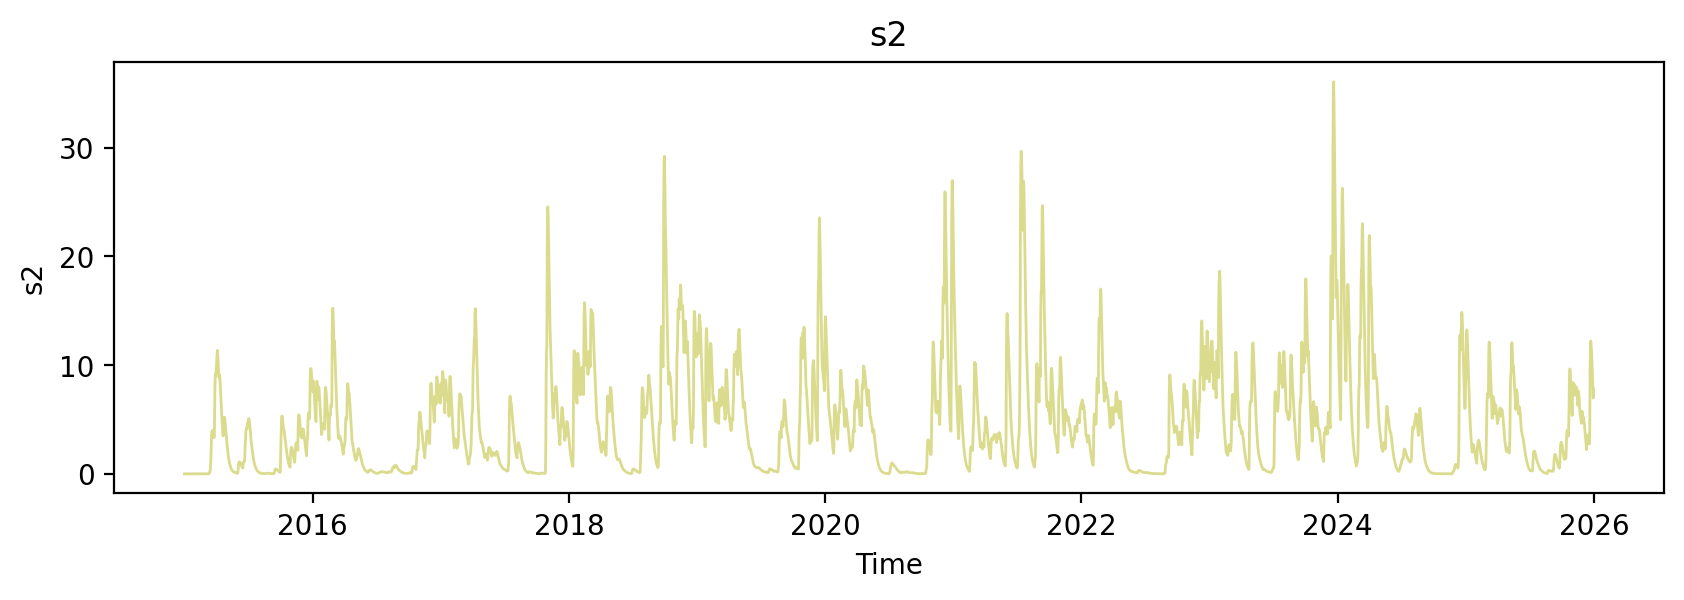

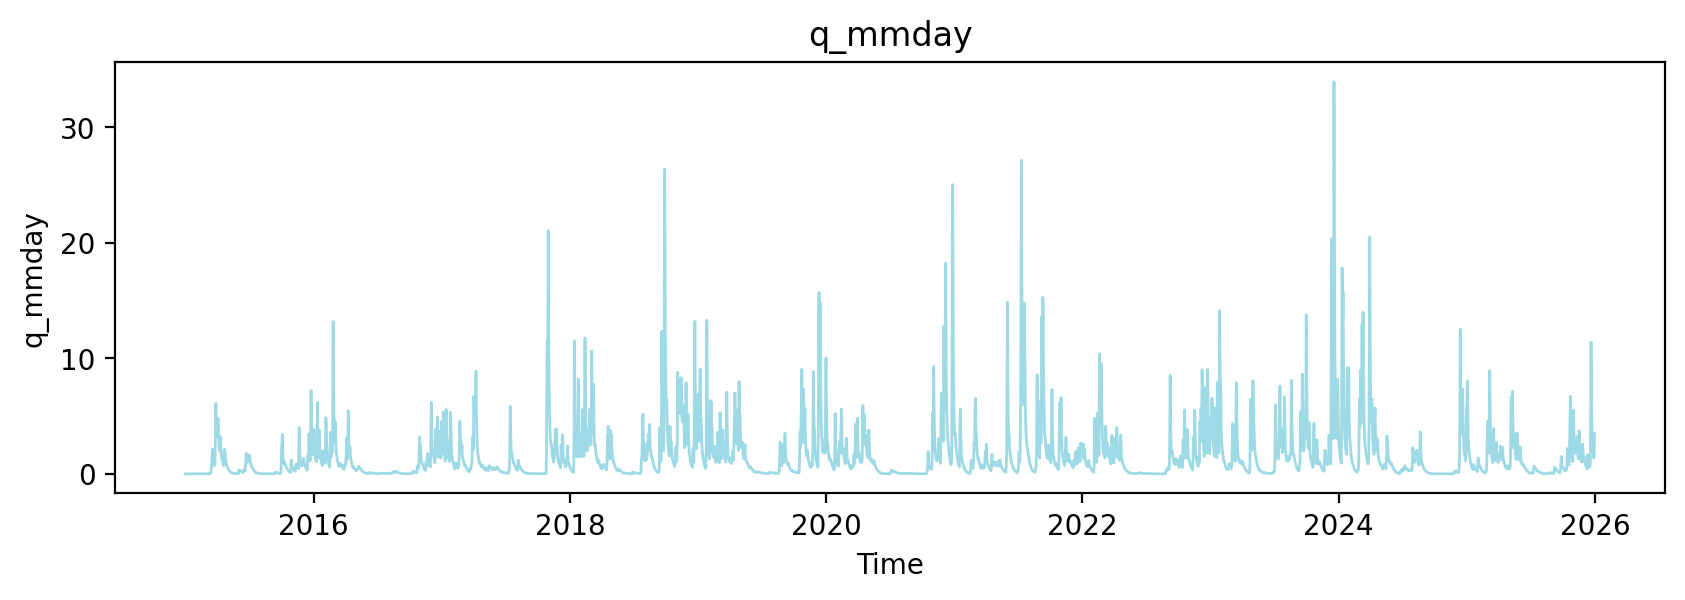

In [20]:
vars_to_plot = [c for c in results.columns if c not in ["Time", "Q_m3s"]]
colors = plt.cm.tab20(np.linspace(0, 1, len(vars_to_plot)))

for v, col in zip(vars_to_plot, colors):
    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.plot(results["Time"], results[v], lw=1, color=col)
    ax.set_xlabel("Time")
    ax.set_ylabel(v)
    ax.set_title(v)
    plt.show()

## S1 and L

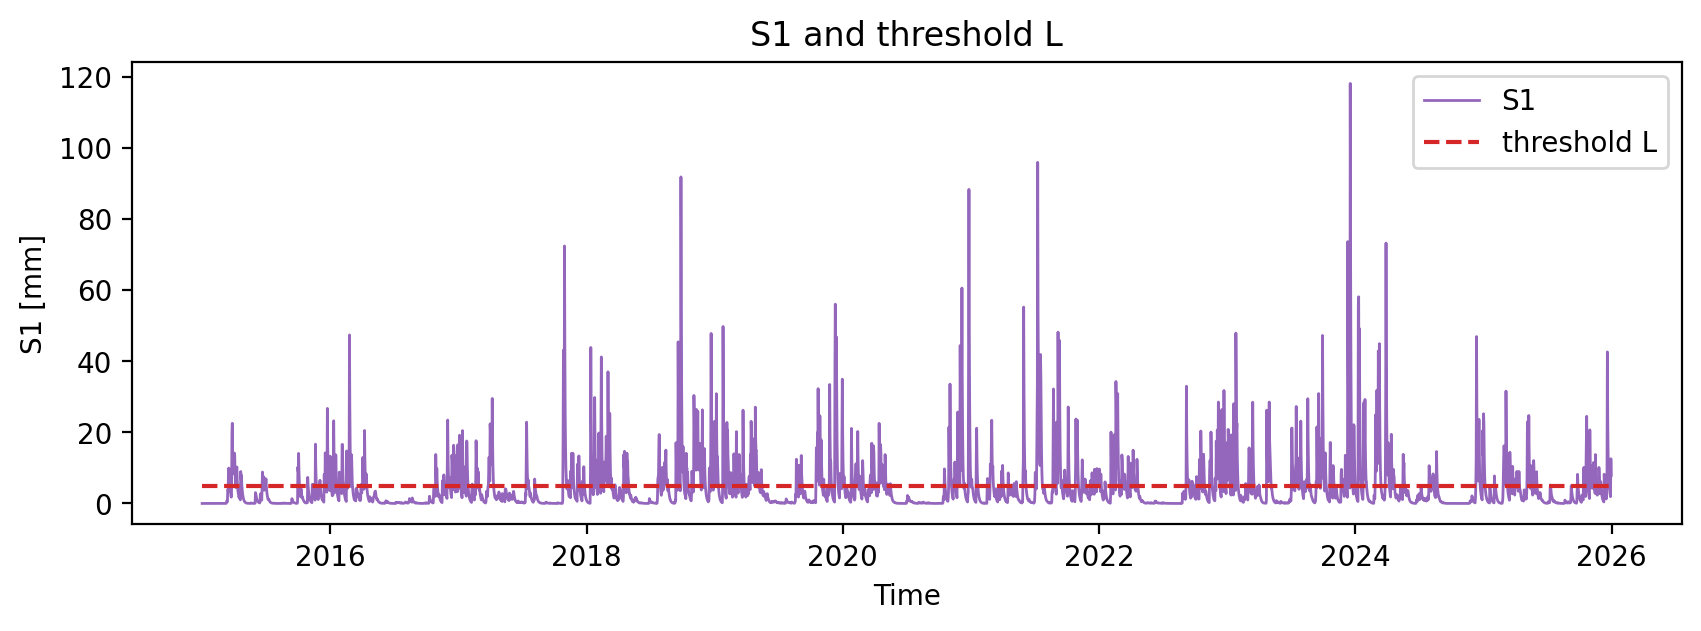

In [21]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(results["Time"], results["s1"], lw=1, label = 'S1',color = 'C4')
ax.hlines(xmin = results["Time"].min(), xmax = results["Time"].max(), y = ParamInitial['lthr'],color = 'C3',linestyles='--',label = 'threshold L')
ax.set_xlabel("Time")
ax.set_ylabel("S1 [mm]")
ax.set_title("S1 and threshold L")
ax.legend()
plt.show()